In [2]:
from farmdar.secrets import set_aws_keys
from farmdar.auth import refresh_token
import s3fs
from farmdar.data import insert_df
import dask_geopandas as dgpd
import dask
from dask.distributed import Client
import re
import geopandas as gpd
import pandas as pd
from datetime import datetime
set_aws_keys()

In [3]:
import s3fs
fs = s3fs.S3FileSystem(anon=False)

# Try listing a folder to test access
fs.ls("centralized-data-storage/BAT/e_sentinel_raw/")


['centralized-data-storage/BAT/e_sentinel_raw/',
 'centralized-data-storage/BAT/e_sentinel_raw/3_2024_2024-10-20_BAT_Crop-Scan']


🟡 Band 1
   Mean abs diff: 0.000000
   Max abs diff: 0.0
   ✅ Pixel-perfect match

🟡 Band 2
   Mean abs diff: 0.000000
   Max abs diff: 0.0
   ✅ Pixel-perfect match

🟡 Band 3
   Mean abs diff: 0.000000
   Max abs diff: 0.0
   ✅ Pixel-perfect match

🟡 Band 4
   Mean abs diff: 0.000000
   Max abs diff: 0.0
   ✅ Pixel-perfect match

🟡 Band 5
   Mean abs diff: 0.000000
   Max abs diff: 0.0
   ✅ Pixel-perfect match

🟡 Band 6
   Mean abs diff: 0.000000
   Max abs diff: 0.0
   ✅ Pixel-perfect match

🟡 Band 7
   Mean abs diff: 0.000000
   Max abs diff: 0.0
   ✅ Pixel-perfect match

🟡 Band 8
   Mean abs diff: 0.000000
   Max abs diff: 0.0
   ✅ Pixel-perfect match


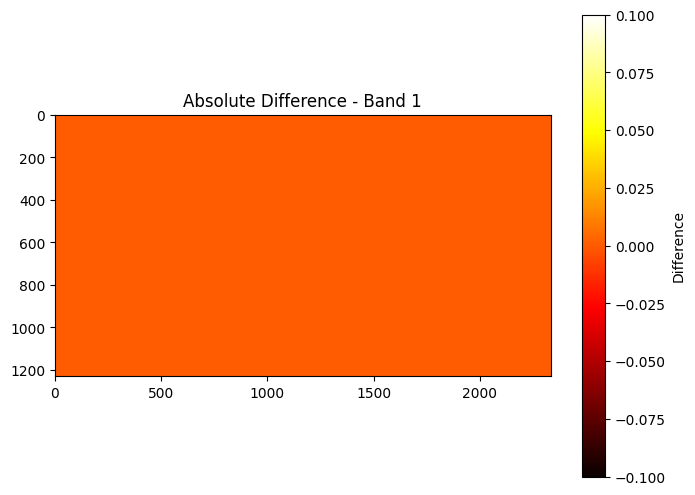

In [4]:
from rasterio.io import MemoryFile
import numpy as np
import matplotlib.pyplot as plt
import fsspec
import xarray as xr

# 1. Load original TIFF from S3
tiff_path = "centralized-data-storage/BAT/b_skywatch_raw/1_2023_2023-04-29_BAT/1_1_3m_2023_2023-04-29_BAT_20230429T0503_573f.tif"
fs = fsspec.filesystem("s3", anon=False)

with fs.open(tiff_path, 'rb') as f:
    tiff_bytes = f.read()

with MemoryFile(tiff_bytes) as memfile:
    with memfile.open() as src:
        tiff_data = src.read()  # shape: (8, 1232, 2334)

# 2. Load Zarr
zarr_path = "s3://centralized-data-storage/zarr/1_1_3m_2023_2023-04-29_BAT_20230429T0503_573f"
fs_map = fsspec.get_mapper(zarr_path, anon=False)
zds = xr.open_zarr(fs_map, consolidated=False)

zarr_data = zds["values"]

# 3. Ensure dimensions are correct
if zarr_data.dims != ("band", "y", "x"):
    zarr_data = zarr_data.transpose("band", "y", "x")

# 4. Convert to numpy
zarr_np = zarr_data.values.astype(tiff_data.dtype)

# 5. Compare bands
for i in range(tiff_data.shape[0]):
    tiff_band = tiff_data[i]
    zarr_band = zarr_np[i]

    mean_diff = np.mean(np.abs(tiff_band - zarr_band))
    max_diff = np.max(np.abs(tiff_band - zarr_band))

    print(f"\n🟡 Band {i+1}")
    print(f"   Mean abs diff: {mean_diff:.6f}")
    print(f"   Max abs diff: {max_diff}")

    if np.array_equal(tiff_band, zarr_band):
        print("   ✅ Pixel-perfect match")
    elif np.allclose(tiff_band, zarr_band, atol=1e-3):
        print("   ✅ Values match within tolerance")
    else:
        print("   ❌ Values differ beyond tolerance")

# 6. Optional visual diff for Band 1
plt.figure(figsize=(8, 6))
plt.imshow(np.abs(tiff_data[0] - zarr_np[0]), cmap="hot")
plt.title("Absolute Difference - Band 1")
plt.colorbar(label="Difference")
plt.show()


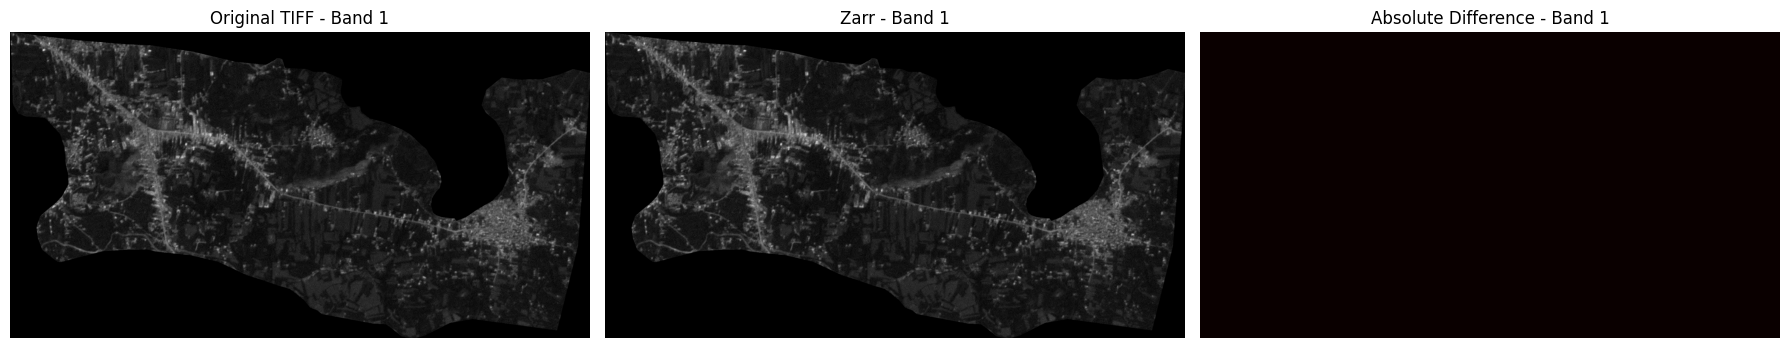

In [5]:
import matplotlib.pyplot as plt

band_index = 0  # 0 for Band 1

tiff_band = tiff_data[band_index]
zarr_band = zarr_data.values[band_index]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original TIFF Band
axes[0].imshow(tiff_band, cmap='gray')
axes[0].set_title(f"Original TIFF - Band {band_index + 1}")
axes[0].axis('off')

# Zarr Band
axes[1].imshow(zarr_band, cmap='gray')
axes[1].set_title(f"Zarr - Band {band_index + 1}")
axes[1].axis('off')

# Difference
diff = tiff_band - zarr_band
axes[2].imshow(np.abs(diff), cmap='hot')
axes[2].set_title(f"Absolute Difference - Band {band_index + 1}")
axes[2].axis('off')

plt.tight_layout()
plt.show()